In [15]:
!pip -q install -U gdown

import os
DATA_DIR = "/content/bodmas"
os.makedirs(DATA_DIR, exist_ok=True)

!gdown --folder "https://drive.google.com/drive/folders/1Uf-LebLWyi9eCv97iBal7kL1NgiGEsv_" -O {DATA_DIR}

!ls -lh /content/bodmas

Using cookies from /root/.cache/gdown/cookies.txt
Retrieving folder contents
Processing file 1_7uhKCrc9hmIOxxfZMoKK6aP8-GJ-DNJ bodmas.npz
Processing file 10bdoOn9qhf647HwANpAga78ye8rOEgwJ bodmas_malware_category.csv
Processing file 16UtiitjekNfqHGlLWtxkxyuU23o2qaja bodmas_metadata.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1_7uhKCrc9hmIOxxfZMoKK6aP8-GJ-DNJ
From (redirected): https://drive.google.com/uc?id=1_7uhKCrc9hmIOxxfZMoKK6aP8-GJ-DNJ&confirm=t&uuid=ba2641ef-b9a5-4220-a449-c29c4d1b37ab
To: /content/bodmas/bodmas.npz
100% 262M/262M [00:02<00:00, 101MB/s]
Downloading...
From: https://drive.google.com/uc?id=10bdoOn9qhf647HwANpAga78ye8rOEgwJ
To: /content/bodmas/bodmas_malware_category.csv
100% 4.12M/4.12M [00:00<00:00, 35.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=16UtiitjekNfqHGlLWtxkxyuU23o2qaja
To: /content/bodmas/bodmas_metadata.csv
100% 1

In [16]:

import numpy as np
import pandas as pd

DATA_DIR = "/content/bodmas"

data = np.load(f"{DATA_DIR}/bodmas.npz")
X, y = data["X"], data["y"]
print("X:", X.shape, X.dtype, f"{X.nbytes/1e9:.2f} GB | y:", y.shape, np.bincount(y))

meta = pd.read_csv(f"{DATA_DIR}/bodmas_metadata.csv")
# malware category file, not used in this analysis
cat  = pd.read_csv(f"{DATA_DIR}/bodmas_malware_category.csv")
print("\nmetadata columns:", list(meta.columns))
print(meta.head(3))
print("\ncategory columns:", list(cat.columns))
print(cat.head(3))

# timestamps
meta["timestamp"] = pd.to_datetime(meta["timestamp"], utc=True, errors="coerce")
print("\nrows aligned with X:", len(meta) == len(X))
print("unparseable timestamps:", meta["timestamp"].isna().sum())
print("time-sorted ascending:", meta["timestamp"].is_monotonic_increasing)
print("range:", meta["timestamp"].min(), "->", meta["timestamp"].max())

# label consistency: empty family should mean benign
fam_missing = meta["family"].isna()
print("\nlabel/family agreement:", ((fam_missing) == (y == 0)).mean())
print("malware families:", meta.loc[~fam_missing, "family"].nunique())

# monthly volume by class, which decides how the temporal split is cut
meta["month"] = meta["timestamp"].dt.to_period("M")
monthly = pd.crosstab(meta["month"], y).rename(columns={0: "benign", 1: "malware"})
print("\n", monthly)

X: (134435, 2381) float32 1.28 GB | y: (134435,) [77142 57293]

metadata columns: ['sha', 'timestamp', 'family']
                                                 sha  \
0  e6d7b4bab32def853ab564410df53fa33172dda1bfd48c...   
1  5af37a058a5bcf2284c183ee98d92b7c66d8f5ce623e92...   
2  5bfbbea150af5cef2d3a93b80ef7c7faea9f564b56045d...   

                   timestamp family  
0  2007-01-01 08:46:39+00:00    NaN  
1  2007-01-26 17:16:30+00:00    NaN  
2  2007-03-21 02:08:53+00:00    NaN  

category columns: ['sha256', 'category']
                                              sha256 category
0  6a695877f571d043fe08d3cc715d9d4b4af85ffe837fa0...     worm
1  9ef9439795cac85e711b59df296a19e7ac43c144035f2f...   trojan
2  32de655f9010d8d152db16c6e5bbad215fa09286a08ff1...     worm

rows aligned with X: True
unparseable timestamps: 3712
time-sorted ascending: False
range: 2007-01-01 08:46:39+00:00 -> 2020-09-30 03:05:27+00:00

label/family agreement: 1.0
malware families: 582

 col_0    benign  mal

/tmp/ipykernel_2115/3690445547.py:31: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  meta["month"] = meta["timestamp"].dt.to_period("M")


In [17]:

raw = pd.read_csv(f"{DATA_DIR}/bodmas_metadata.csv")["timestamp"]


first_pass = pd.to_datetime(raw, utc=True, errors="coerce")
print("examples that failed first pass:\n", raw[first_pass.isna()].head(5).tolist())
print("examples that parsed:\n", raw[first_pass.notna()].head(3).tolist())

# re-parse allowing per-row formats
meta["timestamp"] = pd.to_datetime(raw, utc=True, errors="coerce", format="mixed")
print("\nstill unparseable:", meta["timestamp"].isna().sum())
print("time-sorted ascending:", meta["timestamp"].is_monotonic_increasing)
meta["month"] = meta["timestamp"].dt.tz_localize(None).dt.to_period("M")

# how much data sits before the official collection window?
cutoff = pd.Timestamp("2019-08-01", tz="UTC")
pre = meta["timestamp"] < cutoff
print("\nbefore Aug 2019 -> benign:", int((pre & (y == 0)).sum()),
      "| malware:", int((pre & (y == 1)).sum()))

# full monthly table for the collection window
monthly = pd.crosstab(meta["month"], y).rename(columns={0: "benign", 1: "malware"})
pd.set_option("display.max_rows", 40)
print("\n", monthly.loc["2019-06":])

# family-name sanity: any duplicates that differ only by case/whitespace?
fams = meta["family"].dropna()
print("\nfamilies raw:", fams.nunique(),
      "| after lower/strip:", fams.str.lower().str.strip().nunique())

examples that failed first pass:
 ['2016-10-30 15:59:55', '2017-07-25 10:16:56', '2017-07-25 22:14:03', '2017-07-26 13:22:52', '2017-07-27 03:22:11']
examples that parsed:
 ['2007-01-01 08:46:39+00:00', '2007-01-26 17:16:30+00:00', '2007-03-21 02:08:53+00:00']

still unparseable: 0
time-sorted ascending: True

before Aug 2019 -> benign: 10731 | malware: 0

 col_0    benign  malware
month                   
2019-06      26        0
2019-07      19        0
2019-08    3371      680
2019-09    3463     4061
2019-10    3925     4549
2019-11    3718     2494
2019-12    6120     4039
2020-01    5926     4510
2020-02    3703     4269
2020-03    3577     4990
2020-04    5201     4640
2020-05    6121     5449
2020-06    8182     4217
2020-07    6392     4995
2020-08    2514     3823
2020-09    4198     4577

families raw: 582 | after lower/strip: 581


In [18]:

dupes = (meta["family"].dropna().drop_duplicates()
         .groupby(lambda i: meta.at[i, "family"].lower().strip()).apply(list))
print("merged:", [v for v in dupes if len(v) > 1])
meta["family"] = meta["family"].str.lower().str.strip()
print("families now:", meta["family"].nunique())

print("\nunparseable timestamps:", meta["timestamp"].isna().sum())
print("sorted ascending:", meta["timestamp"].is_monotonic_increasing)
print("before Aug 2019 -> benign:", int((pre & (y == 0)).sum()),
      "| malware:", int((pre & (y == 1)).sum()))

# monthly counts for the collection window, printed as one compact block
m = monthly.loc["2019-06":]
print("\n" + m.to_string())

merged: [['Unknown', 'unknown']]
families now: 581

unparseable timestamps: 0
sorted ascending: True
before Aug 2019 -> benign: 10731 | malware: 0

col_0    benign  malware
month                   
2019-06      26        0
2019-07      19        0
2019-08    3371      680
2019-09    3463     4061
2019-10    3925     4549
2019-11    3718     2494
2019-12    6120     4039
2020-01    5926     4510
2020-02    3703     4269
2020-03    3577     4990
2020-04    5201     4640
2020-05    6121     5449
2020-06    8182     4217
2020-07    6392     4995
2020-08    2514     3823
2020-09    4198     4577


In [19]:
# restrict to the collection window, define temporal split, check 'unknown'
window = meta["timestamp"] >= pd.Timestamp("2019-08-01", tz="UTC")
Xw, yw = X[window.values], y[window.values]
mw = meta.loc[window].reset_index(drop=True)
print("in window:", Xw.shape, np.bincount(yw))

# free the full array; Colab RAM matters with 2381 float32 features
del X, data
import gc; gc.collect()

TRAIN_END = pd.Period("2019-10", "M")
train_mask = (mw["month"] <= TRAIN_END).values
test_months = sorted(mw.loc[~train_mask, "month"].unique())
print("train:", train_mask.sum(), np.bincount(yw[train_mask]))
print("test months:", [str(p) for p in test_months])

# how much malware is labelled 'unknown'?
unk = (mw["family"] == "unknown")
print("\n'unknown' samples: total", int(unk.sum()),
      "| in train", int((unk & train_mask).sum()),
      "| in test", int((unk & ~train_mask).sum()))

in window: (123704, 2381) [66411 57293]
train: 20049 [10759  9290]
test months: ['2019-11', '2019-12', '2020-01', '2020-02', '2020-03', '2020-04', '2020-05', '2020-06', '2020-07', '2020-08', '2020-09']

'unknown' samples: total 7 | in train 3 | in test 4


In [20]:
# shared train/eval helpers + size-matched random-split baseline
import lightgbm as lgb
from sklearn.metrics import f1_score, roc_auc_score

SEED = 42
rng = np.random.default_rng(SEED)
PARAMS = dict(objective="binary", n_estimators=1000, learning_rate=0.05,
              num_leaves=64, feature_fraction=0.5, bagging_fraction=0.8,
              bagging_freq=1, random_state=SEED, n_jobs=-1, verbose=-1)
TARGET_FPR = 0.01

def fit(train_idx):
    """Train LightGBM, holding out 10% of the training set for early stopping + threshold."""
    idx = rng.permutation(train_idx)
    n_val = len(idx) // 10
    val, tr = idx[:n_val], idx[n_val:]
    model = lgb.LGBMClassifier(**PARAMS)
    model.fit(Xw[tr], yw[tr], eval_set=[(Xw[val], yw[val])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    # threshold giving ~1% FPR on held-out benign validation samples
    s_val = model.predict_proba(Xw[val])[:, 1]
    thr = np.quantile(s_val[yw[val] == 0], 1 - TARGET_FPR)
    return model, thr

def evaluate(model, thr, idx):
    s = model.predict_proba(Xw[idx])[:, 1]
    t, pred = yw[idx], (s >= thr).astype(int)
    return dict(n=len(idx), mal_frac=t.mean(),
                auc=roc_auc_score(t, s),
                f1=f1_score(t, pred),
                tpr=pred[t == 1].mean(),
                fpr=pred[t == 0].mean())

# size-matched random split over the same window
n_train = int(train_mask.sum())
perm = rng.permutation(len(yw))
rand_train, rand_test = perm[:n_train], perm[n_train:]

model_rand, thr_rand = fit(rand_train)
res_rand = evaluate(model_rand, thr_rand, rand_test)
print("trees used:", model_rand.best_iteration_, "| threshold:", round(thr_rand, 4))
print({k: round(v, 4) if isinstance(v, float) else v for k, v in res_rand.items()})

trees used: 179 | threshold: 0.1289
{'n': 103655, 'mal_frac': np.float64(0.463), 'auc': np.float64(0.9997), 'f1': 0.9904, 'tpr': np.float64(0.9965), 'fpr': np.float64(0.0136)}


In [21]:
# temporal split: train on Aug–Oct 2019, test on each later month
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

train_idx = np.where(train_mask)[0]
model_temp, thr_temp = fit(train_idx)
print("trees used:", model_temp.best_iteration_, "| threshold:", round(thr_temp, 4))

rows = []
for mth in test_months:
    idx = np.where((mw["month"] == mth).values)[0]
    r = evaluate(model_temp, thr_temp, idx)
    r["month"] = str(mth)
    rows.append(r)

temporal = pd.DataFrame(rows).set_index("month")
print(temporal.round(4).to_string())
print("\nrandom-split reference -> F1 %.4f | TPR %.4f | FPR %.4f"
      % (res_rand["f1"], res_rand["tpr"], res_rand["fpr"]))

trees used: 210 | threshold: 0.0641
             n  mal_frac     auc      f1     tpr     fpr
month                                                   
2019-11   6212    0.4015  0.9996  0.9851  0.9944  0.0164
2019-12  10159    0.3976  0.9999  0.9869  1.0000  0.0175
2020-01  10436    0.4322  0.9989  0.9171  0.9984  0.1362
2020-02   7972    0.5355  0.9966  0.8905  0.9977  0.2800
2020-03   8567    0.5825  0.9990  0.9889  0.9940  0.0226
2020-04   9841    0.4715  0.9998  0.9825  0.9978  0.0298
2020-05  11570    0.4710  0.9999  0.9940  0.9958  0.0070
2020-06  12399    0.3401  0.9999  0.9891  0.9995  0.0111
2020-07  11387    0.4387  0.9997  0.9921  0.9960  0.0092
2020-08   6337    0.6033  0.9996  0.9967  0.9974  0.0060
2020-09   8775    0.5216  0.9995  0.9955  0.9974  0.0069

random-split reference -> F1 0.9904 | TPR 0.9965 | FPR 0.0136


In [22]:
# what are the Jan/Feb 2020 false positives? one burst, or broad drift?
for mth in ["2020-01", "2020-02"]:
    idx = np.where((mw["month"] == pd.Period(mth, "M")).values)[0]
    s = model_temp.predict_proba(Xw[idx])[:, 1]
    fp = idx[(yw[idx] == 0) & (s >= thr_temp)]
    fp_scores = s[(yw[idx] == 0) & (s >= thr_temp)]

    n_unique = len(np.unique(Xw[fp], axis=0))
    days = mw.loc[fp, "timestamp"].dt.date.value_counts()

    print(f"=== {mth}: {len(fp)} false positives of {(yw[idx]==0).sum()} benign ===")
    print(f"unique feature vectors among FPs: {n_unique}")
    print(f"FP score quartiles: {np.round(np.quantile(fp_scores, [.25,.5,.75]), 3)}")
    print(f"days with FPs: {len(days)} | top 5 days:\n{days.head(5).to_string()}\n")

=== 2020-01: 807 false positives of 5926 benign ===
unique feature vectors among FPs: 807
FP score quartiles: [0.154 0.379 0.783]
days with FPs: 2 | top 5 days:
timestamp
2020-01-01    806
2020-01-12      1

=== 2020-02: 1037 false positives of 3703 benign ===
unique feature vectors among FPs: 1037
FP score quartiles: [0.147 0.382 0.854]
days with FPs: 6 | top 5 days:
timestamp
2020-02-26    707
2020-02-19    325
2020-02-23      2
2020-02-15      1
2020-02-22      1



In [23]:
# are the burst days placeholders/batches? What is FPR without them?
first_pass_w = first_pass[window.values].reset_index(drop=True)
burst_days = pd.to_datetime(["2020-01-01", "2020-02-19", "2020-02-26"]).date
day = mw["timestamp"].dt.date

for d in burst_days:
    on_day = (day == d).values
    ben = on_day & (yw == 0)
    t = mw.loc[on_day, "timestamp"]
    print(f"{d}: {on_day.sum()} samples ({ben.sum()} benign, {(on_day & (yw==1)).sum()} malware)"
          f" | all at 00:00:00: {(t.dt.time == pd.Timestamp('00:00').time()).mean():.2%}"
          f" | failed first parse: {first_pass_w[on_day].isna().mean():.2%}")

# FPR per month with and without the burst days
is_burst = day.isin(burst_days).values
rows = []
for mth in test_months:
    in_m = (mw["month"] == mth).values
    s = model_temp.predict_proba(Xw[in_m])[:, 1]
    pred, t, b = (s >= thr_temp), yw[in_m], is_burst[in_m]
    rows.append(dict(month=str(mth),
                     fpr_all=pred[t == 0].mean(),
                     fpr_excl_burst=pred[(t == 0) & ~b].mean(),
                     tpr=pred[t == 1].mean()))
print("\n" + pd.DataFrame(rows).set_index("month").round(4).to_string())

2020-01-01: 5987 samples (5877 benign, 110 malware) | all at 00:00:00: 98.16% | failed first parse: 0.00%
2020-02-19: 1445 samples (1259 benign, 186 malware) | all at 00:00:00: 0.00% | failed first parse: 0.00%
2020-02-26: 2435 samples (2382 benign, 53 malware) | all at 00:00:00: 0.00% | failed first parse: 0.00%

         fpr_all  fpr_excl_burst     tpr
month                                   
2019-11   0.0164          0.0164  0.9944
2019-12   0.0175          0.0175  1.0000
2020-01   0.1362          0.0204  0.9984
2020-02   0.2800          0.0806  0.9977
2020-03   0.0226          0.0226  0.9940
2020-04   0.0298          0.0298  0.9978
2020-05   0.0070          0.0070  0.9958
2020-06   0.0111          0.0111  0.9995
2020-07   0.0092          0.0092  0.9960
2020-08   0.0060          0.0060  0.9974
2020-09   0.0069          0.0069  0.9974


In [24]:
# exclude placeholder-dated samples, then TPR on seen vs unseen families
placeholder = (day == pd.Timestamp("2020-01-01").date()).values
print("dropping placeholder-dated samples:", placeholder.sum())

train_fams = set(mw.loc[train_mask & (yw == 1), "family"]) - {"unknown"}
print("families seen in training:", len(train_fams))

rows = []
for mth in test_months:
    in_m = (mw["month"] == mth).values & ~placeholder
    mal = in_m & (yw == 1) & (mw["family"] != "unknown").values
    s = model_temp.predict_proba(Xw[mal])[:, 1]
    hit = s >= thr_temp
    seen = mw.loc[mal, "family"].isin(train_fams).values
    rows.append(dict(month=str(mth),
                     n_seen=seen.sum(), n_unseen=(~seen).sum(),
                     unseen_frac=(~seen).mean(),
                     tpr_seen=hit[seen].mean() if seen.any() else np.nan,
                     tpr_unseen=hit[~seen].mean() if (~seen).any() else np.nan,
                     med_score_unseen=np.median(s[~seen]) if (~seen).any() else np.nan))

fam_df = pd.DataFrame(rows).set_index("month")
print(fam_df.round(4).to_string())

# pooled over all test months
tot_seen, tot_unseen = fam_df["n_seen"].sum(), fam_df["n_unseen"].sum()
print("\npooled TPR seen: %.4f (n=%d) | unseen: %.4f (n=%d)" % (
    (fam_df["tpr_seen"] * fam_df["n_seen"]).sum() / tot_seen, tot_seen,
    (fam_df["tpr_unseen"] * fam_df["n_unseen"]).sum() / tot_unseen, tot_unseen))

dropping placeholder-dated samples: 5987
families seen in training: 318
         n_seen  n_unseen  unseen_frac  tpr_seen  tpr_unseen  med_score_unseen
month                                                                         
2019-11    2461        33       0.0132    0.9955      0.9091            0.9998
2019-12    4004        33       0.0082    1.0000      1.0000            0.9997
2020-01    4321        79       0.0180    0.9988      0.9747            0.9994
2020-02    4172        97       0.0227    0.9983      0.9691            0.9989
2020-03    4860       130       0.0261    0.9942      0.9846            0.9998
2020-04    4433       207       0.0446    0.9984      0.9855            1.0000
2020-05    4801       648       0.1189    0.9965      0.9907            1.0000
2020-06    4001       214       0.0508    0.9995      1.0000            1.0000
2020-07    4089       906       0.1814    0.9985      0.9845            0.9993
2020-08    3582       241       0.0630    0.9983      0.983

In [25]:
# Wilson 95% CIs for pooled seen/unseen TPR + miss-rate ratio
from statsmodels.stats.proportion import proportion_confint

def pooled(col_tpr, col_n):
    n = int(fam_df[col_n].sum())
    hits = int(np.round((fam_df[col_tpr] * fam_df[col_n]).sum()))
    lo, hi = proportion_confint(hits, n, alpha=0.05, method="wilson")
    return n, hits, hits / n, lo, hi

for name, (ct, cn) in {"seen": ("tpr_seen", "n_seen"),
                       "unseen": ("tpr_unseen", "n_unseen")}.items():
    n, h, p, lo, hi = pooled(ct, cn)
    print(f"{name:>6}: TPR {p:.4f}  95% CI [{lo:.4f}, {hi:.4f}]  misses {n-h}/{n}")

_, _, p_s, _, _ = pooled("tpr_seen", "n_seen")
_, _, p_u, _, _ = pooled("tpr_unseen", "n_unseen")
print(f"\nmiss-rate ratio (unseen / seen): {(1-p_u)/(1-p_s):.1f}x")

  seen: TPR 0.9979  95% CI [0.9974, 0.9982]  misses 96/44767
unseen: TPR 0.9865  95% CI [0.9819, 0.9900]  misses 42/3122

miss-rate ratio (unseen / seen): 6.3x


In [26]:
# robustness: clean random baseline + shorter (Aug–Sep 2019) training window
valid = ~placeholder

# 1) random split without placeholder-dated samples, same training size as before
pool = rng.permutation(np.where(valid)[0])
m_r, t_r = fit(pool[:n_train])
res_clean = evaluate(m_r, t_r, pool[n_train:])
print("clean random split -> AUC %.4f | F1 %.4f | TPR %.4f | FPR %.4f"
      % (res_clean["auc"], res_clean["f1"], res_clean["tpr"], res_clean["fpr"]))

# 2) temporal split with a shorter window
def run_temporal(train_end):
    tr_mask = (mw["month"] <= pd.Period(train_end, "M")).values
    model, thr = fit(np.where(tr_mask)[0])
    fams = set(mw.loc[tr_mask & (yw == 1), "family"]) - {"unknown"}
    rows, s_hits, s_n, u_hits, u_n = [], 0, 0, 0, 0
    for mth in sorted(mw.loc[~tr_mask, "month"].unique()):
        in_m = (mw["month"] == mth).values & valid
        s = model.predict_proba(Xw[in_m])[:, 1]
        pred, t = s >= thr, yw[in_m]
        fam = mw.loc[in_m, "family"].values
        known = (t == 1) & (fam != "unknown")
        seen = known & np.isin(fam, list(fams))
        unseen = known & ~np.isin(fam, list(fams))
        s_hits += pred[seen].sum();   s_n += seen.sum()
        u_hits += pred[unseen].sum(); u_n += unseen.sum()
        rows.append(dict(month=str(mth), tpr=pred[t == 1].mean(), fpr=pred[t == 0].mean(),
                         unseen_frac=unseen.sum() / max(known.sum(), 1)))
    print(f"train <= {train_end}: {tr_mask.sum()} samples, {len(fams)} families | "
          f"pooled TPR seen {s_hits/s_n:.4f} (n={s_n}) | unseen {u_hits/u_n:.4f} (n={u_n}) | "
          f"miss ratio {(1-u_hits/u_n)/(1-s_hits/s_n):.1f}x")
    return pd.DataFrame(rows).set_index("month")

short = run_temporal("2019-09")
print(short.round(4).to_string())

clean random split -> AUC 0.9997 | F1 0.9927 | TPR 0.9949 | FPR 0.0090
train <= 2019-09: 11575 samples, 238 families | pooled TPR seen 0.9949 (n=48578) | unseen 0.9743 (n=3859) | miss ratio 5.0x
            tpr     fpr  unseen_frac
month                               
2019-10  0.9901  0.0064       0.0334
2019-11  0.9916  0.0086       0.0385
2019-12  0.9950  0.0092       0.0151
2020-01  0.9968  0.0000       0.0305
2020-02  0.9939  0.1874       0.0314
2020-03  0.9880  0.0131       0.0333
2020-04  0.9953  0.0200       0.0506
2020-05  0.9917  0.0025       0.1286
2020-06  0.9950  0.0048       0.0605
2020-07  0.9942  0.0038       0.1970
2020-08  0.9956  0.0036       0.0821
2020-09  0.9939  0.0040       0.1370


             n  mal_frac     auc      f1     tpr     fpr  n_benign
month                                                             
2019-11   6212    0.4015  0.9996  0.9851  0.9944  0.0164      3718
2019-12  10159    0.3976  0.9999  0.9869  1.0000  0.0175      6120
2020-01   4449    0.9890  0.9999  0.9991  0.9984  0.0204        49
2020-02   7972    0.5355  0.9966  0.8905  0.9977  0.2800      3703
2020-03   8567    0.5825  0.9990  0.9889  0.9940  0.0226      3577
2020-04   9841    0.4715  0.9998  0.9825  0.9978  0.0298      5201
2020-05  11570    0.4710  0.9999  0.9940  0.9958  0.0070      6121
2020-06  12399    0.3401  0.9999  0.9891  0.9995  0.0111      8182
2020-07  11387    0.4387  0.9997  0.9921  0.9960  0.0092      6392
2020-08   6337    0.6033  0.9996  0.9967  0.9974  0.0060      2514
2020-09   8775    0.5216  0.9995  0.9955  0.9974  0.0069      4198


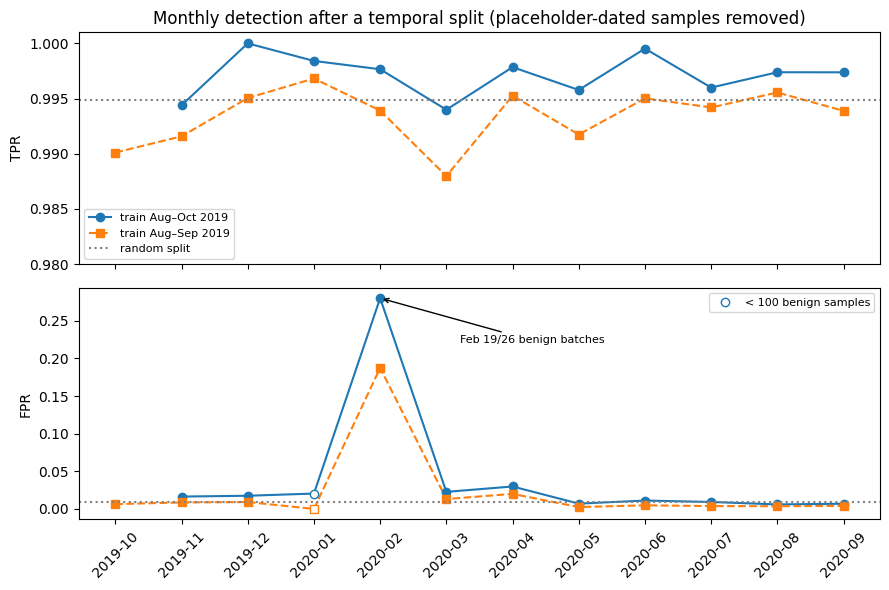

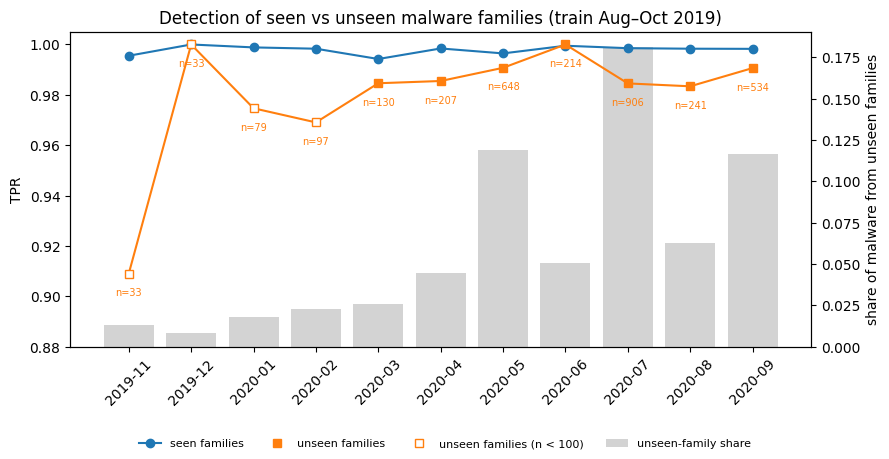

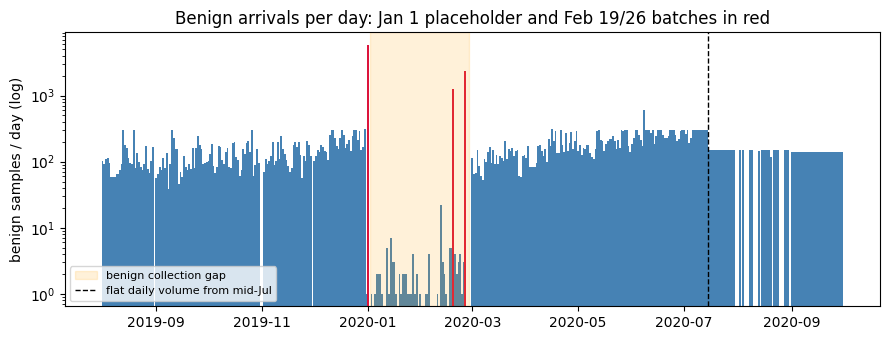

saved figures and tables


In [27]:
# figures + saved results for the README
import matplotlib.pyplot as plt, os
os.makedirs("/content/figs", exist_ok=True); os.makedirs("/content/results", exist_ok=True)

def monthly(model, thr, months):
    rows = []
    for mth in months:
        in_m = (mw["month"] == mth).values & valid
        s = model.predict_proba(Xw[in_m])[:, 1]
        pred, t = s >= thr, yw[in_m]
        rows.append(dict(month=str(mth), n=int(in_m.sum()), mal_frac=t.mean(),
                         auc=roc_auc_score(t, s), f1=f1_score(t, pred.astype(int)),
                         tpr=pred[t == 1].mean(), fpr=pred[t == 0].mean(),
                         n_benign=int((t == 0).sum())))
    return pd.DataFrame(rows).set_index("month")

main = monthly(model_temp, thr_temp, test_months)
print(main.round(4).to_string())
months = list(short.index)
x = np.arange(len(months))

# Fig 1 — hollow markers where a month has < 100 benign samples; label the Feb spike
mm = main.reindex(months)
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
a1.plot(x, mm["tpr"], "o-", label="train Aug–Oct 2019")
a1.plot(x, short["tpr"], "s--", label="train Aug–Sep 2019")
a1.axhline(res_clean["tpr"], color="grey", ls=":", label="random split")
a1.set_ylabel("TPR"); a1.set_ylim(0.98, 1.001); a1.legend(loc="lower left", fontsize=8)
low_b = (mm["n_benign"] < 100).values
a2.plot(x, mm["fpr"], "-", color="C0"); a2.plot(x, short["fpr"], "--", color="C1")
a2.plot(x[~low_b], mm["fpr"][~low_b], "o", color="C0")
a2.plot(x[low_b], mm["fpr"][low_b], "o", mfc="white", color="C0", label="< 100 benign samples")
a2.plot(x[~low_b], short["fpr"][~low_b], "s", color="C1")
a2.plot(x[low_b], short["fpr"][low_b], "s", mfc="white", color="C1")
a2.axhline(res_clean["fpr"], color="grey", ls=":")
feb = months.index("2020-02")
a2.annotate("Feb 19/26 benign batches", (feb, mm["fpr"].iloc[feb]),
            xytext=(feb + 1.2, 0.22), fontsize=8, arrowprops=dict(arrowstyle="->"))
a2.set_ylabel("FPR"); a2.set_xticks(x, months, rotation=45); a2.legend(fontsize=8)
a1.set_title("Monthly detection after a temporal split (placeholder-dated samples removed)")
fig.tight_layout(); fig.savefig("/content/figs/fig1_temporal_tpr_fpr.png", dpi=200); plt.show()

# Fig 2: seen vs unseen family TPR, with unseen share
fx = np.arange(len(fam_df))
n_u = fam_df["n_unseen"].values
low = n_u < 100

fig, ax = plt.subplots(figsize=(9, 4.6))
ax2 = ax.twinx()
ax2.bar(fx, fam_df["unseen_frac"], color="lightgrey", label="unseen-family share")

ax.plot(fx, fam_df["tpr_seen"], "o-", color="C0", label="seen families")
ax.plot(fx, fam_df["tpr_unseen"], "-", color="C1")
ax.plot(fx[~low], fam_df["tpr_unseen"][~low], "s", color="C1", label="unseen families")
ax.plot(fx[low], fam_df["tpr_unseen"][low], "s", mfc="white", color="C1",
        label="unseen families (n < 100)")
for i, (tpr, n) in enumerate(zip(fam_df["tpr_unseen"], n_u)):
    ax.annotate(f"n={n}", (i, tpr), textcoords="offset points", xytext=(0, -16),
                ha="center", fontsize=7, color="C1")

ax.set_zorder(ax2.get_zorder() + 1); ax.patch.set_visible(False)
ax.set_ylabel("TPR"); ax2.set_ylabel("share of malware from unseen families")
ax.set_xticks(fx, fam_df.index, rotation=45); ax.set_ylim(0.88, 1.005)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
fig.legend(h1 + h2, l1 + l2, loc="lower center", ncol=4, fontsize=8, frameon=False)
ax.set_title("Detection of seen vs unseen malware families (train Aug–Oct 2019)")
fig.tight_layout(rect=(0, 0.07, 1, 1))
fig.savefig("/content/figs/fig2_seen_vs_unseen.png", dpi=200); plt.show()

# Fig 3 — daily benign volume: placeholder date, Feb batches, Jan–Feb gap, mid-July change
daily = mw.loc[yw == 0].groupby(mw["timestamp"].dt.date).size()
flag = pd.Index(daily.index).isin(list(burst_days))
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(daily.index, daily.values, color=np.where(flag, "crimson", "steelblue"), width=1)
ax.axvspan(pd.Timestamp("2020-01-02"), pd.Timestamp("2020-02-28"), color="orange", alpha=0.15,
           label="benign collection gap")
ax.axvline(pd.Timestamp("2020-07-15"), color="black", ls="--", lw=1,
           label="flat daily volume from mid-Jul")
ax.set_yscale("log"); ax.set_ylabel("benign samples / day (log)")
ax.legend(loc="lower left", fontsize=8)
ax.set_title("Benign arrivals per day: Jan 1 placeholder and Feb 19/26 batches in red")
fig.tight_layout(); fig.savefig("/content/figs/fig3_benign_daily.png", dpi=200); plt.show()

# save tables
main.to_csv("/content/results/temporal_aug-oct.csv")
short.to_csv("/content/results/temporal_aug-sep.csv")
fam_df.to_csv("/content/results/seen_vs_unseen.csv")
print("saved figures and tables")

In [28]:
# quantify the benign collection regimes
d = pd.Series(daily.values, index=pd.to_datetime(daily.index))
periods = {"Aug–Dec 2019": ("2019-08-01", "2019-12-31"),
           "Jan 2–Feb 25 2020 (excl. bursts)": ("2020-01-02", "2020-02-25"),
           "Mar 1–Jul 14 2020": ("2020-03-01", "2020-07-14"),
           "Jul 15–Sep 30 2020": ("2020-07-15", "2020-09-30")}
for name, (a, b) in periods.items():
    s = d[a:b].drop(pd.to_datetime(list(burst_days)), errors="ignore")
    print(f"{name:>34}: days {len(s):3d} | median/day {s.median():6.0f} | "
          f"std {s.std():6.1f} | total {s.sum():6d}")

                      Aug–Dec 2019: days 149 | median/day    121 | std   68.3 | total  20597
  Jan 2–Feb 25 2020 (excl. bursts): days  40 | median/day      2 | std    3.5 | total    111
                 Mar 1–Jul 14 2020: days 136 | median/day    183 | std   84.6 | total  27055
                Jul 15–Sep 30 2020: days  63 | median/day    147 | std    6.7 | total   9130
